# Notebook de Testeo de Modelos de Regresion

Este notebook contiene 3 modelos separados por Markdown:
- Regresion Lineal
- Random Forest Regressor
- XGBoost Regressor

Cada modelo incluye metricas y su importancia de variables.

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set(style="whitegrid")

In [14]:
DATA_PATH = "../data/raw/kc_house_data.csv"
TARGET = "price"
RANDOM_STATE = 42
TEST_SIZE = 0.2

def evaluar_modelo(nombre, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{nombre}")
    print(f"MAE : {mae:,.2f}")
    print(f"RMSE: {rmse:,.2f}")
    print(f"R2  : {r2:.4f}")

def plot_importancia(df_importancia, titulo, top_n=15):
    top = df_importancia.sort_values("importance", ascending=False).head(top_n)
    plt.figure(figsize=(10, 6))
    sns.barplot(data=top, x="importance", y="feature", palette="Blues_r")
    plt.title(titulo)
    plt.xlabel("Importancia")
    plt.ylabel("Variable")
    plt.tight_layout()
    plt.show()

## Carga y Preparacion de Datos

In [15]:
data_modelo = pd.read_csv(DATA_PATH)
data_modelo['zipcode']=data_modelo['zipcode'].astype('category')
anio_actual = pd.Timestamp.today().year  

data_modelo['data_modelod_fabricacion'] = anio_actual - data_modelo['yr_built']
data_modelo['data_modelod_renovacion'] = np.where(data_modelo['yr_renovated'] > 0, anio_actual - data_modelo['yr_renovated'], np.nan)
if "date" in data_modelo.columns:
    data_modelo["date"] = pd.to_datetime(data_modelo["date"], format="%Y%m%dT%H%M%S", errors="coerce")
    data_modelo["sale_year"] = data_modelo["date"].dt.year
    data_modelo["sale_month"] = data_modelo["date"].dt.month
    data_modelo["sale_day"] = data_modelo["date"].dt.day

data_modelo = data_modelo.drop(columns=["id", "date"], errors="ignore")


In [16]:
data_modelo.columns


Index(['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long',
       'sqft_living15', 'sqft_lot15', 'data_modelod_fabricacion',
       'data_modelod_renovacion', 'sale_year', 'sale_month', 'sale_day'],
      dtype='object')

In [17]:

data_modelo=data_modelo.drop(columns=['yr_built', 'yr_renovated','sale_year', 'sale_month', 'sale_day'])

In [18]:
X = data_modelo.drop(columns=[TARGET])
y = data_modelo[TARGET]

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

print(f"Shape train: {X_train.shape}")
print(f"Shape test : {X_test.shape}")
X.head()

Shape train: (17290, 86)
Shape test : (4323, 86)


,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,...,zipcode_98146,zipcode_98148,zipcode_98155,zipcode_98166,zipcode_98168,zipcode_98177,zipcode_98178,zipcode_98188,zipcode_98198,zipcode_98199
0,3,1.00,1180,5650,1.0,0,0,3,7,1180,...,False,False,False,False,False,False,True,False,False,False
1,3,2.25,2570,7242,2.0,0,0,3,7,2170,...,False,False,False,False,False,False,False,False,False,False
2,2,1.00,770,10000,1.0,0,0,3,6,770,...,False,False,False,False,False,False,False,False,False,False
3,4,3.00,1960,5000,1.0,0,0,5,7,1050,...,False,False,False,False,False,False,False,False,False,False
4,3,2.00,1680,8080,1.0,0,0,3,8,1680,...,False,False,False,False,False,False,False,False,False,False


## 3) XGBoost Regressor

In [19]:
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("xgboost") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "xgboost"])

from xgboost import XGBRegressor

xgb_reg = XGBRegressor(
    n_estimators=600,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgb_reg.fit(X_train, y_train)

y_pred_xgb = xgb_reg.predict(X_test)
evaluar_modelo("XGBoost", y_test, y_pred_xgb)

xgb_importancia = pd.DataFrame(
    {
        "feature": X_train.columns,
        "importance": xgb_reg.feature_importances_
    }
).sort_values("importance", ascending=False)

xgb_importancia.head(15)

XGBoost
MAE : 66,438.45
RMSE: 136,227.56
R2  : 0.8772


,feature,importance
8,grade,0.234403
5,waterfront,0.131175
2,sqft_living,0.072781
40,zipcode_98039,0.060384
19,zipcode_98004,0.057198
29,zipcode_98023,0.047340
11,lat,0.042036
64,zipcode_98112,0.029453
6,view,0.025336
12,long,0.020543


C:\Users\USER\AppData\Local\Temp\ipykernel_26152\1124420392.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top, x="importance", y="feature", palette="Blues_r")


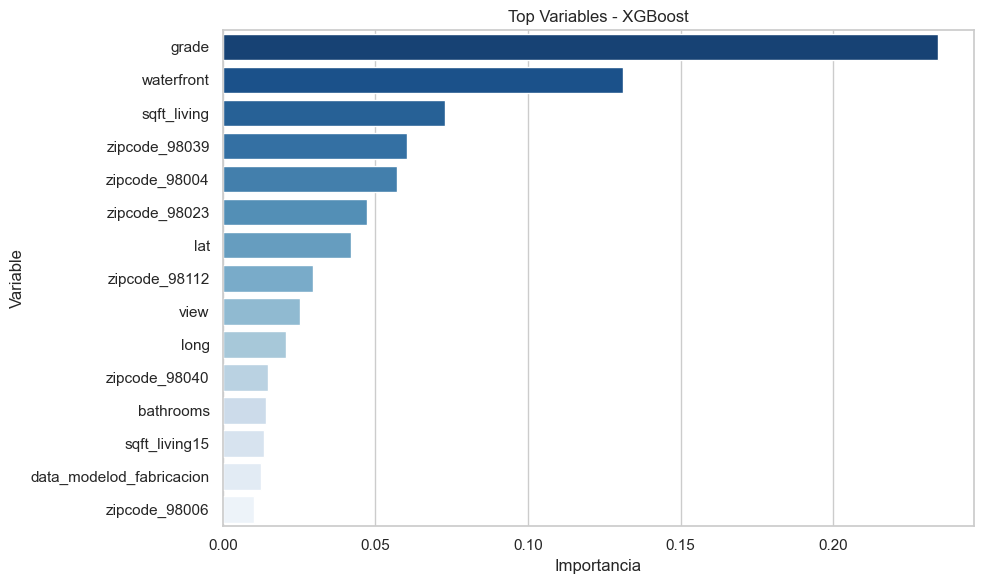

In [20]:
plot_importancia(xgb_importancia, "Top Variables - XGBoost", top_n=15)

# Comparacion para eliminacion de variables 